# Fase 3 – Análisis exploratorio de datos

## Análisis estadístico, temporal y espacial de PM2.5

**Proyecto:** Identificación de zonas críticas de contaminación atmosférica mediante técnicas GIS y aprendizaje automático utilizando concentraciones de PM2.5 registradas en la Ciudad de México durante el periodo 2024–2025.

**Responsable técnico:** Miranda Patricia Pérez Camelo

## Objetivo

Analizar el comportamiento estadístico, temporal y espacial de las concentraciones de PM2.5 y su relación con las variables meteorológicas de temperatura, humedad relativa, velocidad del viento y dirección del viento.

El análisis permitirá identificar patrones, estaciones con mayores concentraciones y relaciones preliminares entre las condiciones meteorológicas y la contaminación atmosférica.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
CARPETA_PROYECTO = Path("..")
CARPETA_RESULTADOS = CARPETA_PROYECTO / "resultados"
CARPETA_FIGURAS = CARPETA_RESULTADOS / "figuras"
CARPETA_TABLAS = CARPETA_RESULTADOS / "tablas"

CARPETA_FIGURAS.mkdir(parents=True, exist_ok=True)
CARPETA_TABLAS.mkdir(parents=True, exist_ok=True)

RUTA_DATASET = (
    CARPETA_RESULTADOS
    / "dataset_analisis_pm25_2024_2025.csv"
)

print("Dataset:", RUTA_DATASET.resolve())
print("Existe:", RUTA_DATASET.exists())

Dataset: C:\Users\pmiri\OneDrive\Desktop\ProyAmbiental\resultados\dataset_analisis_pm25_2024_2025.csv
Existe: True


## 1. Carga y validación del dataset

Se utilizará el dataset consolidado que contiene únicamente registros con concentraciones de PM2.5 disponibles. Las demás variables meteorológicas pueden contener valores faltantes cuando una estación no reportó determinada variable.

In [3]:
datos = pd.read_csv(
    RUTA_DATASET,
    parse_dates=["DATETIME", "FECHA"],
    low_memory=False
)

print("Dataset cargado correctamente")
print("Dimensiones:", datos.shape)

datos.head()

Dataset cargado correctamente
Dimensiones: (206858, 19)


,DATETIME,FECHA,HORA,ANIO,MES,DIA,DIA_SEMANA,HORA_DIA,ESTACION,nom_estac,PM25,TMP,RH,WSP,WDR,longitud,latitud,alt,id_station
0,2024-01-01,2024-01-01,1,2024,1,1,0,0,AJM,Ajusco Medio,33.0,6.0,57.0,3.5,320.0,-99.207744,19.272161,2548.0,484090120609
1,2024-01-01,2024-01-01,1,2024,1,1,0,0,BJU,Benito Juárez,42.0,12.0,56.0,0.8,173.0,-99.159596,19.370464,2249.0,484090140201
2,2024-01-01,2024-01-01,1,2024,1,1,0,0,CAM,Camarones,46.0,NaN,NaN,NaN,NaN,-99.169794,19.468404,2233.0,484090020301
3,2024-01-01,2024-01-01,1,2024,1,1,0,0,MER,Merced,52.0,14.0,56.0,0.7,304.0,-99.119594,19.424610,2245.0,484090170127
4,2024-01-01,2024-01-01,1,2024,1,1,0,0,MPA,Milpa Alta,33.0,7.0,60.0,NaN,NaN,-98.990189,19.176900,2594.0,484090090104


In [4]:
print(datos.columns.tolist())

['DATETIME', 'FECHA', 'HORA', 'ANIO', 'MES', 'DIA', 'DIA_SEMANA', 'HORA_DIA', 'ESTACION', 'nom_estac', 'PM25', 'TMP', 'RH', 'WSP', 'WDR', 'longitud', 'latitud', 'alt', 'id_station']


In [5]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 206858 entries, 0 to 206857
Data columns (total 19 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   DATETIME    206858 non-null  datetime64[us]
 1   FECHA       206858 non-null  datetime64[us]
 2   HORA        206858 non-null  int64         
 3   ANIO        206858 non-null  int64         
 4   MES         206858 non-null  int64         
 5   DIA         206858 non-null  int64         
 6   DIA_SEMANA  206858 non-null  int64         
 7   HORA_DIA    206858 non-null  int64         
 8   ESTACION    206858 non-null  str           
 9   nom_estac   206858 non-null  str           
 10  PM25        206858 non-null  float64       
 11  TMP         119968 non-null  float64       
 12  RH          150007 non-null  float64       
 13  WSP         136582 non-null  float64       
 14  WDR         136584 non-null  float64       
 15  longitud    206858 non-null  float64       
 16  latitud     2

In [6]:
duplicados = datos.duplicated(
    subset=["DATETIME", "ESTACION"]
).sum()

print("Duplicados:", duplicados)

Duplicados: 0


In [7]:
datos_trabajo = datos.copy()

print("Copia de trabajo creada")

Copia de trabajo creada


In [8]:
registros_rh_negativa = datos_trabajo["RH"] < 0

print(
    "Registros con humedad negativa:",
    registros_rh_negativa.sum()
)

datos_trabajo.loc[
    registros_rh_negativa,
    "RH"
] = np.nan

print(
    "Valores negativos después del ajuste:",
    (datos_trabajo["RH"] < 0).sum()
)

Registros con humedad negativa: 3
Valores negativos después del ajuste: 0


### Nota de control de calidad

Se detectaron tres valores negativos de humedad relativa. Debido a que este tipo de valor no es físicamente válido, se sustituyeron por valores faltantes únicamente en la copia utilizada para el análisis. Los archivos originales permanecieron sin modificaciones.

## 2. Estadística descriptiva

Se calcularán medidas de tendencia central y dispersión para conocer el comportamiento general de PM2.5 y las variables meteorológicas.

In [9]:
variables_numericas = [
    "PM25",
    "TMP",
    "RH",
    "WSP",
    "WDR",
    "alt"
]

estadisticas = datos_trabajo[
    variables_numericas
].describe().T

estadisticas

,count,mean,std,min,25%,50%,75%,max
PM25,206858.0,20.150954,12.548452,1.0,11.00,18.0,26.0,312.0
TMP,119968.0,17.973353,5.166085,-2.5,14.50,17.6,21.5,35.9
RH,150004.0,50.870003,22.769027,0.0,33.00,50.0,70.0,100.0
WSP,136582.0,2.022457,1.248166,0.0,1.12,1.8,2.6,11.1
WDR,136584.0,169.500959,112.631489,0.0,64.00,162.0,270.0,360.0
alt,206858.0,2338.768580,198.249860,2221.0,2234.00,2249.0,2311.0,3082.0


In [10]:
estadisticas["mediana"] = datos_trabajo[
    variables_numericas
].median()

estadisticas["faltantes"] = datos_trabajo[
    variables_numericas
].isna().sum()

estadisticas["porcentaje_faltante"] = (
    datos_trabajo[variables_numericas]
    .isna()
    .mean()
    .mul(100)
    .round(2)
)

estadisticas

,count,mean,std,min,25%,50%,75%,max,mediana,faltantes,porcentaje_faltante
PM25,206858.0,20.150954,12.548452,1.0,11.00,18.0,26.0,312.0,18.0,0,0.00
TMP,119968.0,17.973353,5.166085,-2.5,14.50,17.6,21.5,35.9,17.6,86890,42.00
RH,150004.0,50.870003,22.769027,0.0,33.00,50.0,70.0,100.0,50.0,56854,27.48
WSP,136582.0,2.022457,1.248166,0.0,1.12,1.8,2.6,11.1,1.8,70276,33.97
WDR,136584.0,169.500959,112.631489,0.0,64.00,162.0,270.0,360.0,162.0,70274,33.97
alt,206858.0,2338.768580,198.249860,2221.0,2234.00,2249.0,2311.0,3082.0,2249.0,0,0.00


In [11]:
ruta_estadisticas = (
    CARPETA_TABLAS
    / "estadisticas_descriptivas.csv"
)

estadisticas.to_csv(
    ruta_estadisticas,
    encoding="utf-8-sig"
)

print("Tabla guardada:", ruta_estadisticas.exists())

Tabla guardada: True


## 3. Disponibilidad de los datos

Se evaluará el porcentaje de registros disponibles y faltantes para cada variable. Esta revisión permitirá determinar qué variables poseen suficiente información para los análisis y modelos posteriores.

In [12]:
resumen_nulos = pd.DataFrame({
    "disponibles": datos_trabajo[
        variables_numericas
    ].notna().sum(),

    "faltantes": datos_trabajo[
        variables_numericas
    ].isna().sum(),

    "porcentaje_faltante": (
        datos_trabajo[variables_numericas]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
}).sort_values(
    by="porcentaje_faltante",
    ascending=False
)

resumen_nulos

,disponibles,faltantes,porcentaje_faltante
TMP,119968,86890,42.00
WSP,136582,70276,33.97
WDR,136584,70274,33.97
RH,150004,56854,27.48
PM25,206858,0,0.00
alt,206858,0,0.00


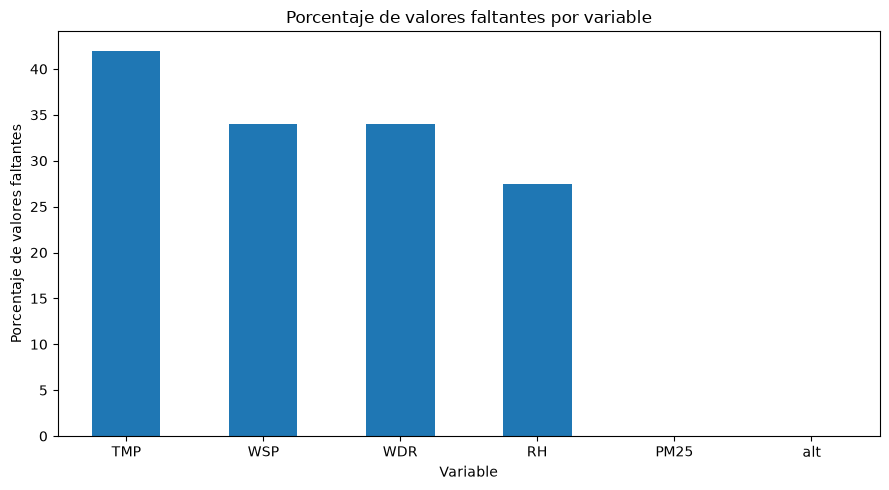

In [13]:
ax = resumen_nulos["porcentaje_faltante"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Porcentaje de valores faltantes por variable")
plt.xlabel("Variable")
plt.ylabel("Porcentaje de valores faltantes")
plt.xticks(rotation=0)
plt.tight_layout()

ruta_figura = (
    CARPETA_FIGURAS
    / "porcentaje_valores_faltantes.png"
)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Distribución de las concentraciones de PM2.5

Se analizará la distribución de las concentraciones para identificar su tendencia central, dispersión, asimetría y posibles valores extremos.

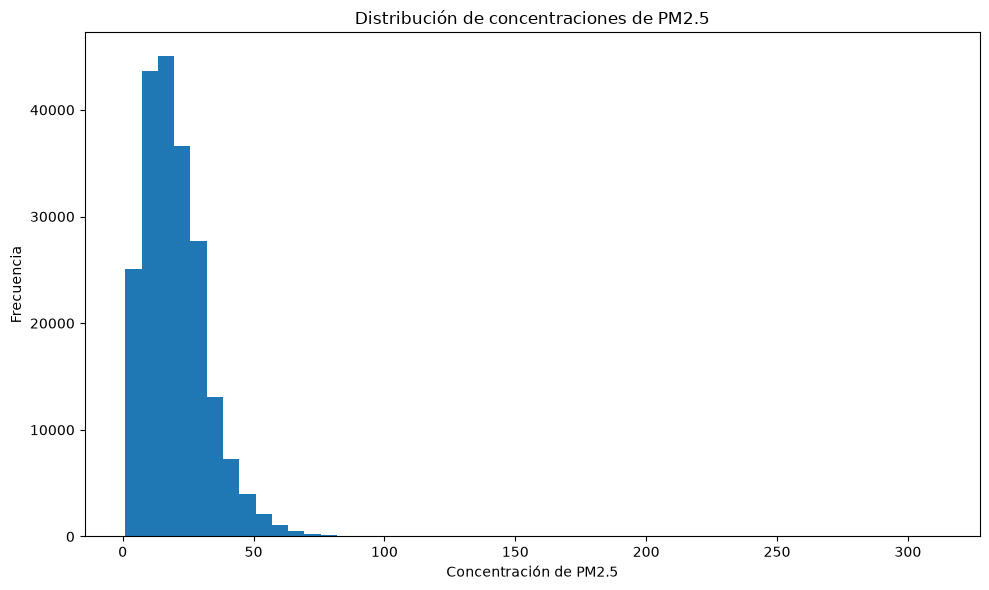

In [14]:
pm25_valido = datos_trabajo["PM25"].dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    pm25_valido,
    bins=50
)

plt.title("Distribución de concentraciones de PM2.5")
plt.xlabel("Concentración de PM2.5")
plt.ylabel("Frecuencia")
plt.tight_layout()

ruta_figura = (
    CARPETA_FIGURAS
    / "distribucion_pm25.png"
)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\pmiri\AppData\Local\Temp\ipykernel_16812\1043388700.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


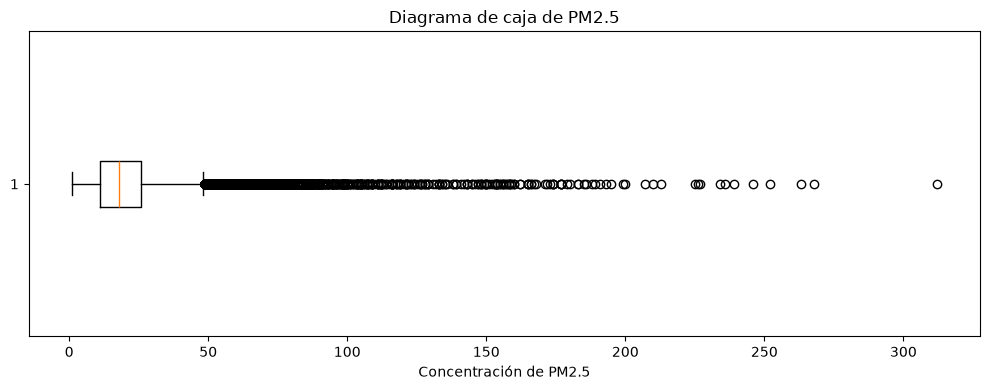

In [15]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    pm25_valido,
    vert=False
)

plt.title("Diagrama de caja de PM2.5")
plt.xlabel("Concentración de PM2.5")
plt.tight_layout()

ruta_figura = (
    CARPETA_FIGURAS
    / "boxplot_pm25.png"
)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
percentiles_pm25 = pm25_valido.quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

percentiles_pm25

0.25    11.0
0.50    18.0
0.75    26.0
0.90    36.0
0.95    42.0
0.99    58.0
Name: PM25, dtype: float64

## 5. Comparación anual

Se compararán las concentraciones promedio de PM2.5 entre 2024 y 2025 para identificar posibles cambios generales entre ambos periodos.

In [17]:
resumen_anual = (
    datos_trabajo
    .groupby("ANIO")["PM25"]
    .agg(
        registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max",
        desviacion="std"
    )
    .round(2)
)

resumen_anual

,registros,promedio,mediana,minimo,maximo,desviacion
ANIO,,,,,,
2024,105873,20.64,18.0,1.0,312.0,13.26
2025,100985,19.64,18.0,1.0,268.0,11.73


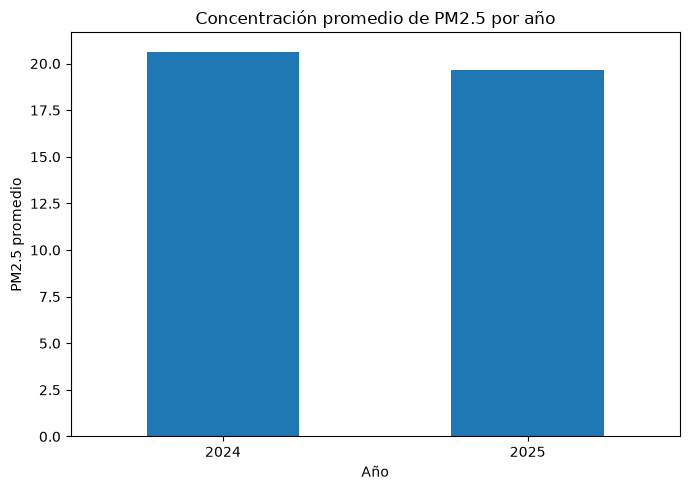

In [18]:
promedio_anual = (
    datos_trabajo
    .groupby("ANIO")["PM25"]
    .mean()
)

promedio_anual.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Concentración promedio de PM2.5 por año")
plt.xlabel("Año")
plt.ylabel("PM2.5 promedio")
plt.xticks(rotation=0)
plt.tight_layout()

ruta_figura = (
    CARPETA_FIGURAS
    / "pm25_promedio_anual.png"
)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Comportamiento mensual de PM2.5

Se calcularán las concentraciones promedio mensuales para identificar periodos del año con mayores o menores niveles de contaminación.

In [19]:
promedio_mensual = (
    datos_trabajo
    .groupby(["ANIO", "MES"])["PM25"]
    .mean()
    .reset_index()
)

promedio_mensual.head()

,ANIO,MES,PM25
0,2024,1,19.387774
1,2024,2,20.781042
2,2024,3,23.917751
3,2024,4,25.060628
4,2024,5,29.170534


In [20]:
tabla_mensual = promedio_mensual.pivot(
    index="MES",
    columns="ANIO",
    values="PM25"
)

tabla_mensual

ANIO,2024,2025
MES,,
1,19.387774,21.460078
2,20.781042,20.752386
3,23.917751,22.184992
4,25.060628,23.673358
5,29.170534,22.235023
6,18.261845,14.352441
7,16.478510,16.028643
8,14.030358,13.886405
9,16.353962,13.330884


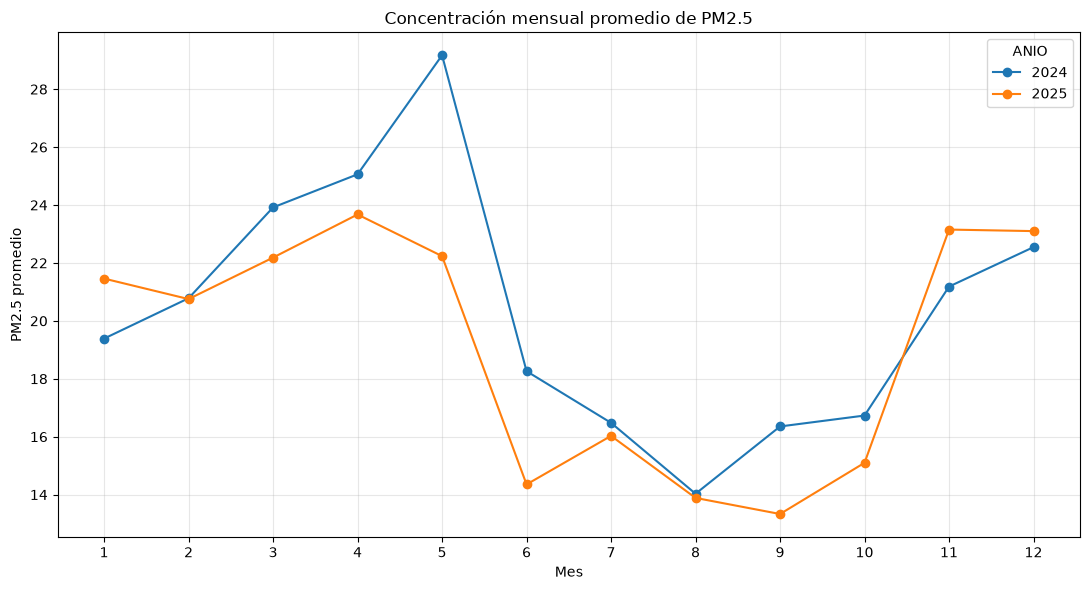

In [21]:
tabla_mensual.plot(
    figsize=(11, 6),
    marker="o"
)

plt.title("Concentración mensual promedio de PM2.5")
plt.xlabel("Mes")
plt.ylabel("PM2.5 promedio")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()

ruta_figura = (
    CARPETA_FIGURAS
    / "pm25_promedio_mensual.png"
)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Comportamiento horario de PM2.5

Se analizará el promedio de PM2.5 para cada hora del día con el propósito de identificar patrones horarios de acumulación o dispersión de contaminantes.

In [22]:
promedio_horario = (
    datos_trabajo
    .groupby("HORA_DIA")["PM25"]
    .mean()
)

promedio_horario

HORA_DIA
0     17.264943
1     17.766667
2     17.737647
3     17.933993
4     18.473406
5     19.153996
6     20.005610
7     21.207094
8     23.086917
9     25.209790
10    26.964454
11    26.909419
12    24.929571
13    22.779119
14    21.261206
15    20.092082
16    19.298497
17    18.705773
18    18.193860
19    17.822338
20    17.365718
21    17.189763
22    17.077482
23    17.228717
Name: PM25, dtype: float64

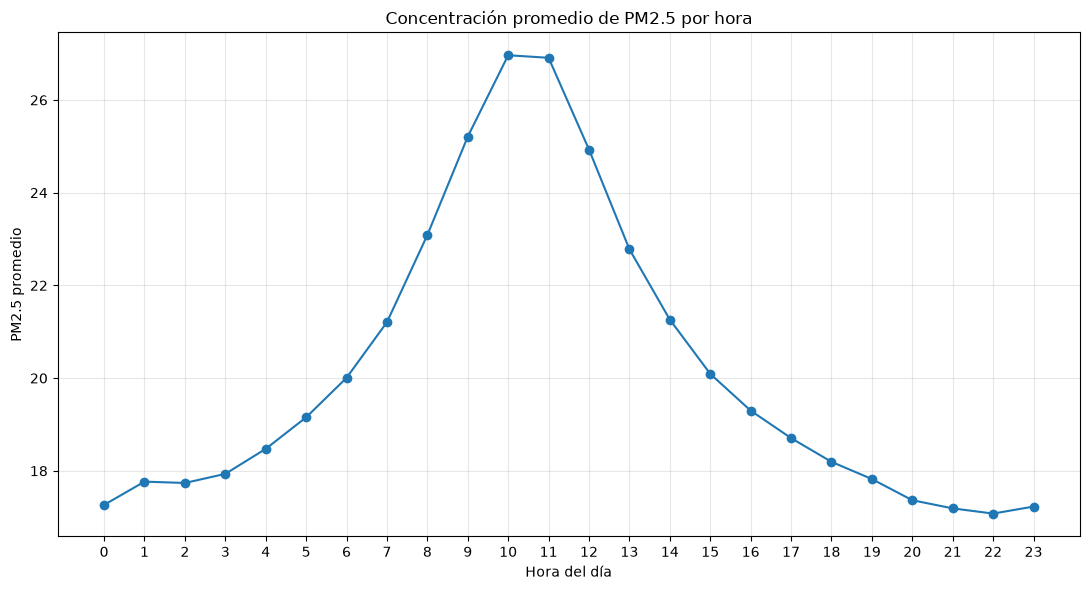

In [23]:
promedio_horario.plot(
    figsize=(11, 6),
    marker="o"
)

plt.title("Concentración promedio de PM2.5 por hora")
plt.xlabel("Hora del día")
plt.ylabel("PM2.5 promedio")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()

ruta_figura = (
    CARPETA_FIGURAS
    / "pm25_promedio_horario.png"
)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Comportamiento por día de la semana

Se evaluará la concentración promedio de PM2.5 para cada día de la semana con el objetivo de identificar posibles diferencias entre días laborales y fines de semana.

In [24]:
nombres_dias = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

datos_trabajo["NOMBRE_DIA"] = (
    datos_trabajo["DIA_SEMANA"]
    .map(nombres_dias)
)

In [25]:
orden_dias = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

promedio_dia = (
    datos_trabajo
    .groupby("NOMBRE_DIA")["PM25"]
    .mean()
    .reindex(orden_dias)
)

promedio_dia

NOMBRE_DIA
Lunes        19.059836
Martes       20.368060
Miércoles    21.367493
Jueves       20.213450
Viernes      20.633190
Sábado       20.358586
Domingo      19.007505
Name: PM25, dtype: float64

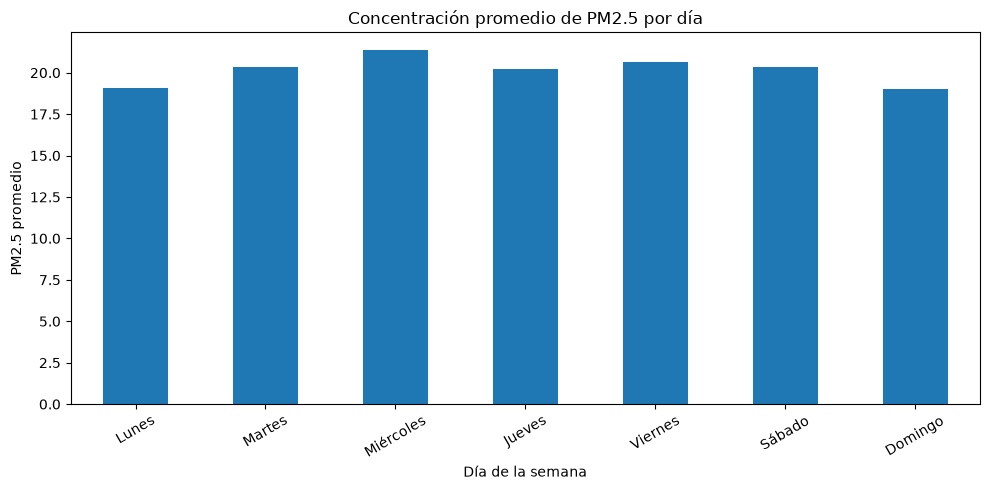

In [26]:
promedio_dia.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Concentración promedio de PM2.5 por día")
plt.xlabel("Día de la semana")
plt.ylabel("PM2.5 promedio")
plt.xticks(rotation=30)
plt.tight_layout()

ruta_figura = (
    CARPETA_FIGURAS
    / "pm25_promedio_dia_semana.png"
)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Relación entre PM2.5 y variables meteorológicas

Se analizará la correlación lineal entre PM2.5, temperatura, humedad relativa, velocidad del viento y dirección del viento.

La correlación permite identificar asociaciones estadísticas, pero no demuestra causalidad.

In [27]:
variables_correlacion = [
    "PM25",
    "TMP",
    "RH",
    "WSP",
    "WDR"
]

datos_correlacion = datos_trabajo[
    variables_correlacion
].dropna().copy()

print(
    "Registros utilizados para correlación:",
    len(datos_correlacion)
)

Registros utilizados para correlación: 108057


In [28]:
matriz_correlacion = (
    datos_correlacion
    .corr()
    .round(3)
)

matriz_correlacion

,PM25,TMP,RH,WSP,WDR
PM25,1.000,0.155,-0.191,-0.114,-0.112
TMP,0.155,1.000,-0.668,0.402,-0.064
RH,-0.191,-0.668,1.000,-0.403,0.033
WSP,-0.114,0.402,-0.403,1.000,0.062
WDR,-0.112,-0.064,0.033,0.062,1.000


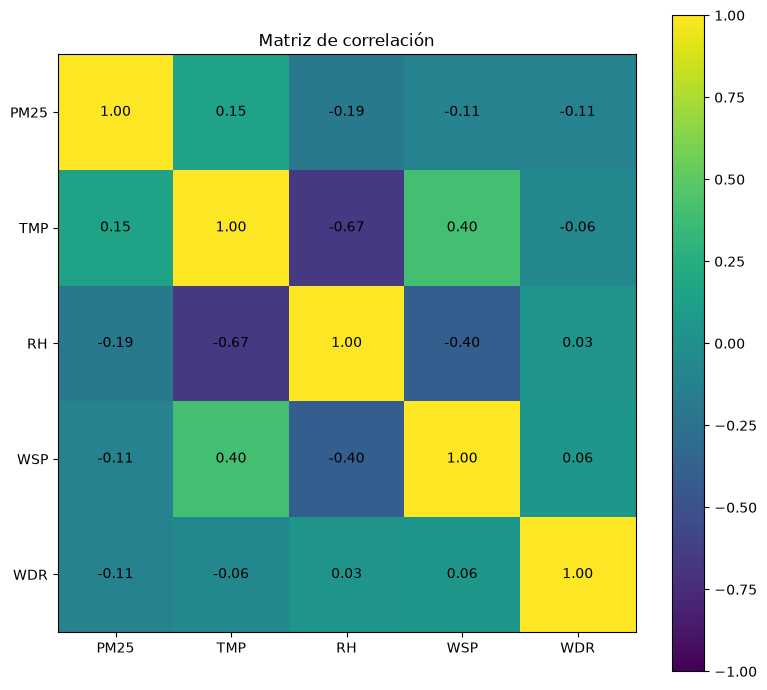

In [29]:
fig, ax = plt.subplots(figsize=(8, 7))

imagen = ax.imshow(
    matriz_correlacion,
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    range(len(matriz_correlacion.columns))
)

ax.set_yticks(
    range(len(matriz_correlacion.index))
)

ax.set_xticklabels(
    matriz_correlacion.columns
)

ax.set_yticklabels(
    matriz_correlacion.index
)

for fila in range(len(matriz_correlacion.index)):
    for columna in range(len(matriz_correlacion.columns)):
        valor = matriz_correlacion.iloc[
            fila,
            columna
        ]

        ax.text(
            columna,
            fila,
            f"{valor:.2f}",
            ha="center",
            va="center"
        )

plt.title("Matriz de correlación")
plt.colorbar(imagen)
plt.tight_layout()

ruta_figura = (
    CARPETA_FIGURAS
    / "matriz_correlacion.png"
)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
tamano_muestra = min(
    10000,
    len(datos_correlacion)
)

muestra = datos_correlacion.sample(
    n=tamano_muestra,
    random_state=42
)

print("Tamaño de la muestra:", len(muestra))

Tamaño de la muestra: 10000


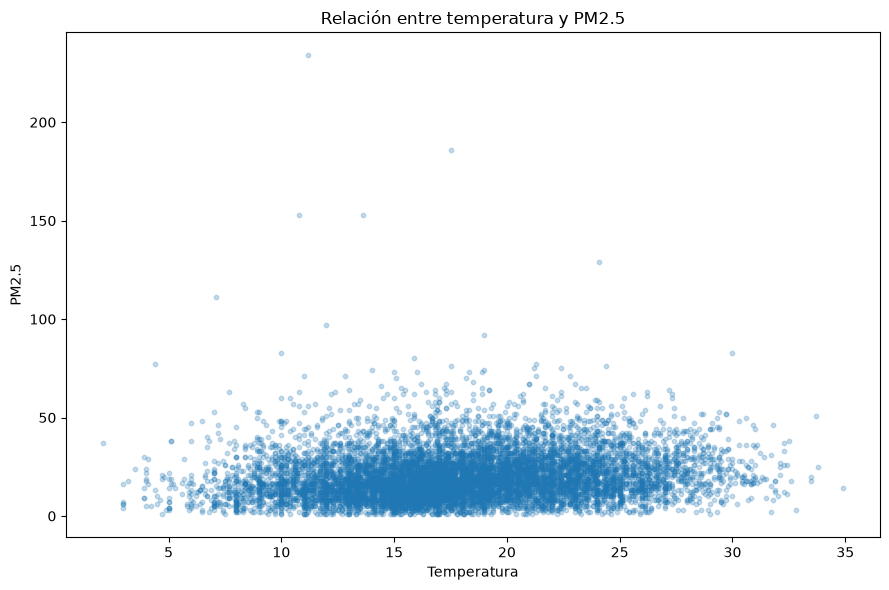

In [31]:
plt.figure(figsize=(9, 6))

plt.scatter(
    muestra["TMP"],
    muestra["PM25"],
    alpha=0.25,
    s=10
)

plt.title("Relación entre temperatura y PM2.5")
plt.xlabel("Temperatura")
plt.ylabel("PM2.5")
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS / "pm25_vs_temperatura.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

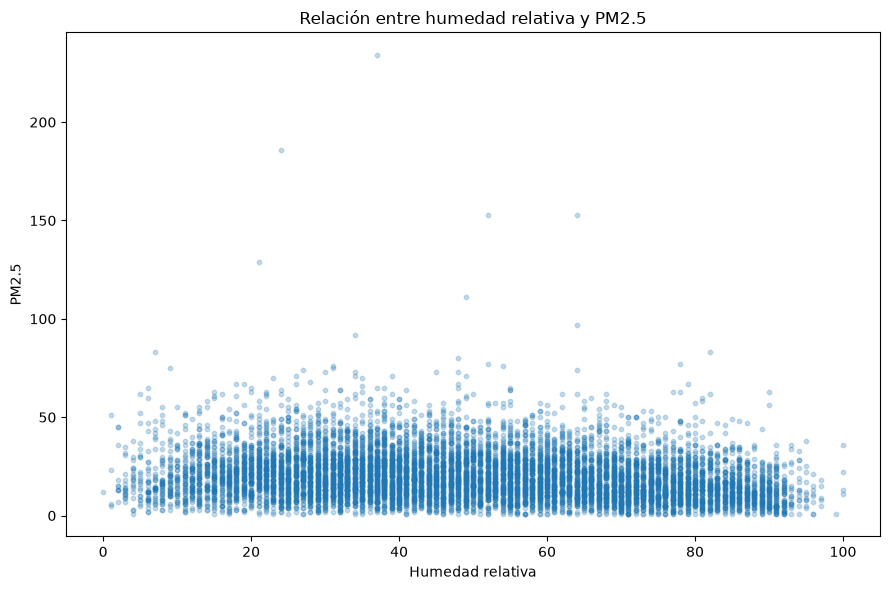

In [32]:
plt.figure(figsize=(9, 6))

plt.scatter(
    muestra["RH"],
    muestra["PM25"],
    alpha=0.25,
    s=10
)

plt.title("Relación entre humedad relativa y PM2.5")
plt.xlabel("Humedad relativa")
plt.ylabel("PM2.5")
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS / "pm25_vs_humedad.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

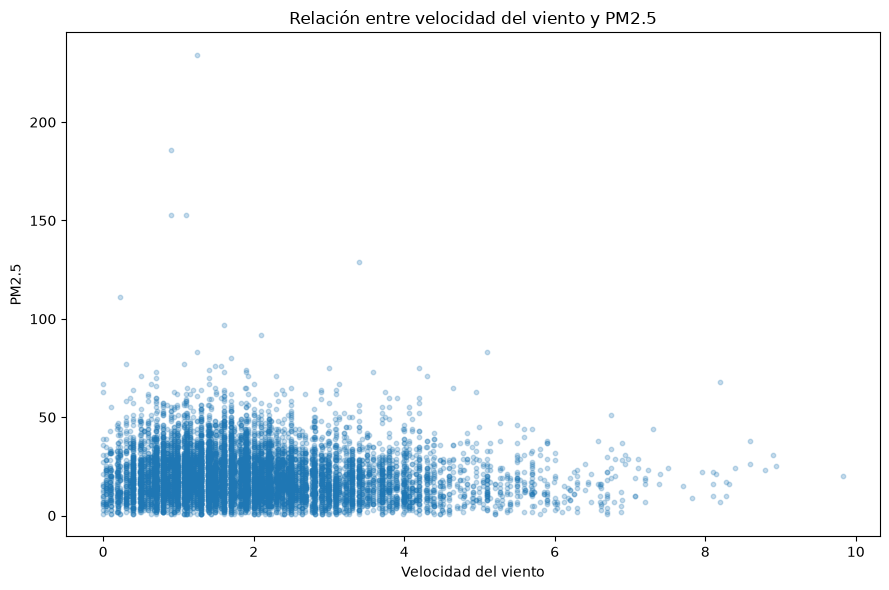

In [33]:
plt.figure(figsize=(9, 6))

plt.scatter(
    muestra["WSP"],
    muestra["PM25"],
    alpha=0.25,
    s=10
)

plt.title("Relación entre velocidad del viento y PM2.5")
plt.xlabel("Velocidad del viento")
plt.ylabel("PM2.5")
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS / "pm25_vs_velocidad_viento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Comportamiento de PM2.5 por estación

Se calcularán estadísticas por estación para identificar puntos de monitoreo con concentraciones promedio más elevadas.

Para evitar interpretaciones basadas en pocas observaciones, se considerará el número de registros disponibles en cada estación.

In [34]:
resumen_estaciones = (
    datos_trabajo
    .groupby(
        [
            "ESTACION",
            "nom_estac",
            "longitud",
            "latitud",
            "alt"
        ],
        as_index=False
    )
    .agg(
        registros=("PM25", "count"),
        promedio_pm25=("PM25", "mean"),
        mediana_pm25=("PM25", "median"),
        maximo_pm25=("PM25", "max"),
        desviacion_pm25=("PM25", "std")
    )
)

resumen_estaciones[
    [
        "promedio_pm25",
        "mediana_pm25",
        "maximo_pm25",
        "desviacion_pm25"
    ]
] = resumen_estaciones[
    [
        "promedio_pm25",
        "mediana_pm25",
        "maximo_pm25",
        "desviacion_pm25"
    ]
].round(2)

resumen_estaciones.head()

,ESTACION,nom_estac,longitud,latitud,alt,registros,promedio_pm25,mediana_pm25,maximo_pm25,desviacion_pm25
0,AJM,Ajusco Medio,-99.207744,19.272161,2548.0,13307,17.41,15.0,98.0,10.68
1,AJU,Ajusco,-99.162611,19.154286,2942.0,2101,16.71,16.0,92.0,8.98
2,BJU,Benito Juárez,-99.159596,19.370464,2249.0,11643,21.12,19.0,159.0,12.26
3,CAM,Camarones,-99.169794,19.468404,2233.0,12409,22.66,21.0,142.0,12.83
4,CCA,Centro de Ciencias de la Atmósfera,-99.176111,19.326111,2294.0,16198,17.06,15.0,109.0,10.22


In [35]:
resumen_estaciones.sort_values(
    by="registros",
    ascending=False
).head(10)

,ESTACION,nom_estac,longitud,latitud,alt,registros,promedio_pm25,mediana_pm25,maximo_pm25,desviacion_pm25
4,CCA,Centro de Ciencias de la Atmósfera,-99.176111,19.326111,2294.0,16198,17.06,15.0,109.0,10.22
13,PED,Pedregal,-99.204136,19.325146,2326.0,15450,18.27,16.0,129.0,10.81
9,MER,Merced,-99.119594,19.424610,2245.0,14976,21.97,20.0,160.0,12.85
0,AJM,Ajusco Medio,-99.207744,19.272161,2548.0,13307,17.41,15.0,98.0,10.68
5,FAR,FES Aragón,-99.046176,19.473692,2230.0,13024,18.71,17.0,195.0,11.60
16,TLA,Tlalnepantla,-99.204597,19.529077,2311.0,12576,21.87,20.0,102.0,12.33
3,CAM,Camarones,-99.169794,19.468404,2233.0,12409,22.66,21.0,142.0,12.83
14,SAC,Santiago Acahualtepec,-99.009381,19.345610,2293.0,12178,26.17,24.0,312.0,16.25
11,MPA,Milpa Alta,-98.990189,19.176900,2594.0,11888,16.89,15.0,133.0,10.85
2,BJU,Benito Juárez,-99.159596,19.370464,2249.0,11643,21.12,19.0,159.0,12.26


In [36]:
MINIMO_REGISTROS = 1000

estaciones_representativas = (
    resumen_estaciones[
        resumen_estaciones["registros"]
        >= MINIMO_REGISTROS
    ]
    .copy()
)

print(
    "Estaciones representativas:",
    len(estaciones_representativas)
)

Estaciones representativas: 19


In [37]:
top_estaciones = (
    estaciones_representativas
    .sort_values(
        by="promedio_pm25",
        ascending=False
    )
    .head(10)
)

top_estaciones[
    [
        "ESTACION",
        "nom_estac",
        "registros",
        "promedio_pm25",
        "maximo_pm25"
    ]
]

,ESTACION,nom_estac,registros,promedio_pm25,maximo_pm25
14,SAC,Santiago Acahualtepec,12178,26.17,312.0
15,SAG,San Agustín,7495,23.04,227.0
3,CAM,Camarones,12409,22.66,142.0
9,MER,Merced,14976,21.97,160.0
7,HGM,Hospital General de México,5856,21.90,173.0
16,TLA,Tlalnepantla,12576,21.87,102.0
18,UIZ,UAM Iztapalapa,10978,21.84,236.0
6,GAM,Gustavo A. Madero,10751,21.53,98.0
2,BJU,Benito Juárez,11643,21.12,159.0
12,NEZ,Nezahualcóyotl,10263,21.09,268.0


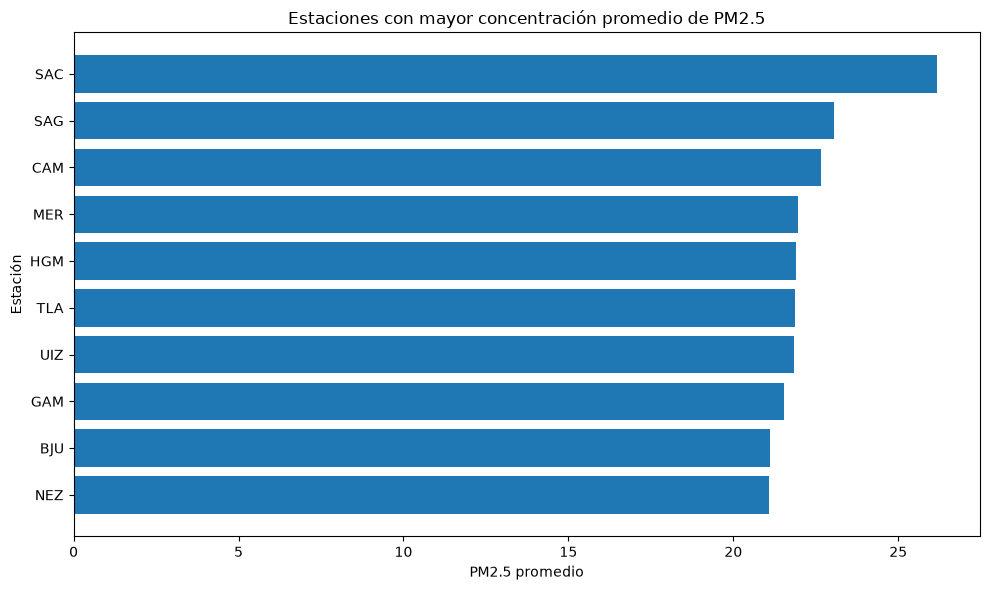

In [38]:
top_grafica = (
    top_estaciones
    .sort_values(
        by="promedio_pm25",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_grafica["ESTACION"],
    top_grafica["promedio_pm25"]
)

plt.title(
    "Estaciones con mayor concentración promedio de PM2.5"
)
plt.xlabel("PM2.5 promedio")
plt.ylabel("Estación")
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS / "top_estaciones_pm25.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Distribución espacial del promedio de PM2.5

Se representará espacialmente la concentración promedio registrada por cada estación de monitoreo. El tamaño y color de los puntos permitirán observar diferencias relativas entre estaciones.

Este mapa representa estaciones de monitoreo y no una interpolación continua de toda la Ciudad de México.

In [39]:
estaciones_pm25_gdf = gpd.GeoDataFrame(
    estaciones_representativas,
    geometry=gpd.points_from_xy(
        estaciones_representativas["longitud"],
        estaciones_representativas["latitud"]
    ),
    crs="EPSG:4326"
)

estaciones_pm25_gdf.head()

,ESTACION,nom_estac,longitud,latitud,alt,registros,promedio_pm25,mediana_pm25,maximo_pm25,desviacion_pm25,geometry
0,AJM,Ajusco Medio,-99.207744,19.272161,2548.0,13307,17.41,15.0,98.0,10.68,POINT (-99.20774 19.27216)
1,AJU,Ajusco,-99.162611,19.154286,2942.0,2101,16.71,16.0,92.0,8.98,POINT (-99.16261 19.15429)
2,BJU,Benito Juárez,-99.159596,19.370464,2249.0,11643,21.12,19.0,159.0,12.26,POINT (-99.1596 19.37046)
3,CAM,Camarones,-99.169794,19.468404,2233.0,12409,22.66,21.0,142.0,12.83,POINT (-99.16979 19.4684)
4,CCA,Centro de Ciencias de la Atmósfera,-99.176111,19.326111,2294.0,16198,17.06,15.0,109.0,10.22,POINT (-99.17611 19.32611)


In [40]:
RUTA_ALCALDIAS = (
    CARPETA_PROYECTO
    / "datos"
    / "datos_limpios"
    / "dataset_limpios"
    / "dataset_limpios"
    / "Geografia"
    / "Alcaldias_CDMX_Limpio.gpkg"
)

print("Existe:", RUTA_ALCALDIAS.exists())

alcaldias = gpd.read_file(RUTA_ALCALDIAS)

print("CRS de alcaldías:", alcaldias.crs)

Existe: True
CRS de alcaldías: EPSG:4326


In [41]:
estaciones_pm25_mapa = (
    estaciones_pm25_gdf
    .to_crs(alcaldias.crs)
)

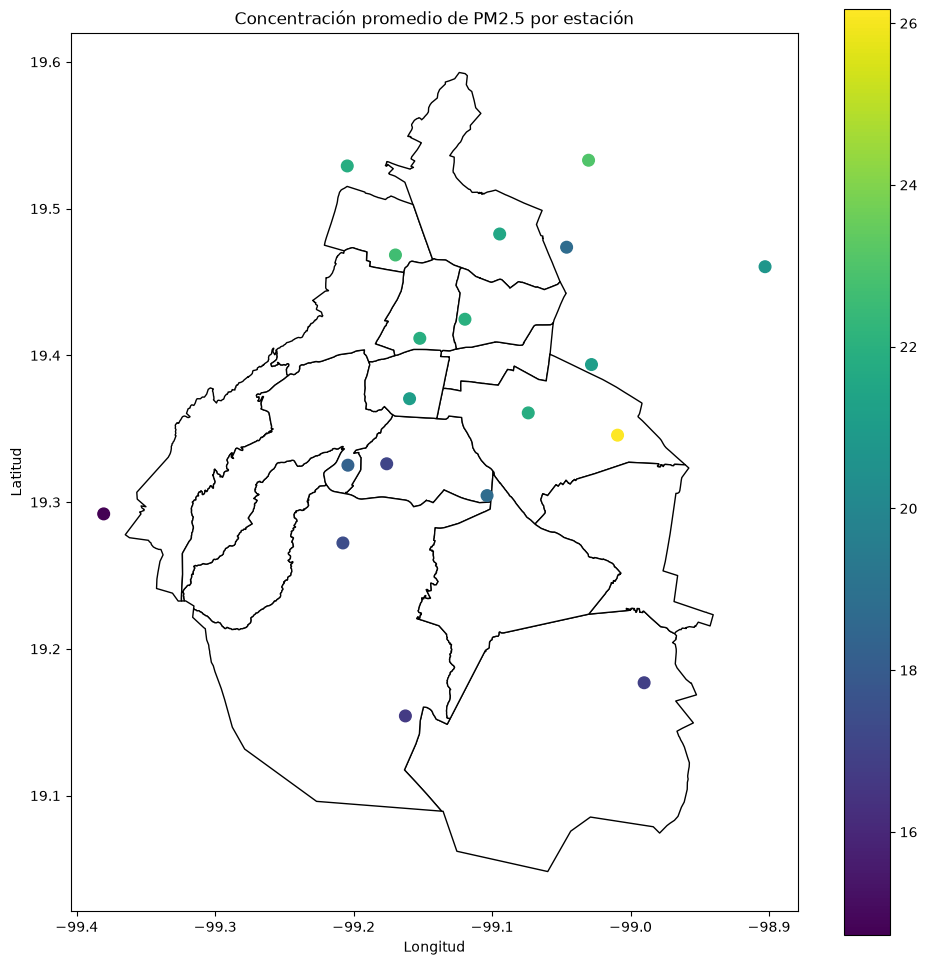

In [42]:
fig, ax = plt.subplots(figsize=(10, 10))

alcaldias.plot(
    ax=ax,
    facecolor="white",
    edgecolor="black"
)

estaciones_pm25_mapa.plot(
    ax=ax,
    column="promedio_pm25",
    legend=True,
    markersize=70
)

plt.title(
    "Concentración promedio de PM2.5 por estación"
)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "mapa_promedio_pm25_estaciones.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12. Identificación preliminar de estaciones con concentraciones elevadas

Mientras se define el criterio ambiental oficial de “zona crítica”, se utilizará de manera exploratoria el percentil 90 de la concentración promedio por estación.

Este criterio es únicamente estadístico y no sustituye normas, límites regulatorios ni criterios de salud pública.

In [43]:
umbral_exploratorio = (
    estaciones_representativas[
        "promedio_pm25"
    ]
    .quantile(0.90)
)

print(
    "Umbral exploratorio del percentil 90:",
    round(umbral_exploratorio, 2)
)

Umbral exploratorio del percentil 90: 22.74


In [44]:
estaciones_representativas[
    "CRITICA_EXPLORATORIA"
] = np.where(
    estaciones_representativas[
        "promedio_pm25"
    ] >= umbral_exploratorio,
    "Sí",
    "No"
)

estaciones_criticas = (
    estaciones_representativas[
        estaciones_representativas[
            "CRITICA_EXPLORATORIA"
        ] == "Sí"
    ]
    .sort_values(
        by="promedio_pm25",
        ascending=False
    )
)

estaciones_criticas[
    [
        "ESTACION",
        "nom_estac",
        "registros",
        "promedio_pm25",
        "maximo_pm25"
    ]
]

,ESTACION,nom_estac,registros,promedio_pm25,maximo_pm25
14,SAC,Santiago Acahualtepec,12178,26.17,312.0
15,SAG,San Agustín,7495,23.04,227.0


In [45]:
resumen_estaciones.to_csv(
    CARPETA_TABLAS / "resumen_pm25_por_estacion.csv",
    index=False,
    encoding="utf-8-sig"
)

In [46]:
promedio_mensual.to_csv(
    CARPETA_TABLAS / "promedio_pm25_mensual.csv",
    index=False,
    encoding="utf-8-sig"
)

In [47]:
matriz_correlacion.to_csv(
    CARPETA_TABLAS / "matriz_correlacion.csv",
    encoding="utf-8-sig"
)

In [48]:
estaciones_criticas.to_csv(
    CARPETA_TABLAS
    / "estaciones_criticas_exploratorias.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tablas guardadas correctamente")

Tablas guardadas correctamente


In [49]:
figuras_generadas = sorted(
    CARPETA_FIGURAS.glob("*.png")
)

print("Cantidad de figuras:", len(figuras_generadas))

for figura in figuras_generadas:
    print(figura.name)

Cantidad de figuras: 13
boxplot_pm25.png
distribucion_pm25.png
mapa_promedio_pm25_estaciones.png
matriz_correlacion.png
pm25_promedio_anual.png
pm25_promedio_dia_semana.png
pm25_promedio_horario.png
pm25_promedio_mensual.png
pm25_vs_humedad.png
pm25_vs_temperatura.png
pm25_vs_velocidad_viento.png
porcentaje_valores_faltantes.png
top_estaciones_pm25.png


# Conclusiones del análisis exploratorio

Se realizó un análisis estadístico, temporal y espacial de las concentraciones de PM2.5 registradas durante 2024 y 2025.

La estadística descriptiva permitió conocer la tendencia central, dispersión y distribución de las concentraciones. También se evaluó la disponibilidad de las variables meteorológicas y se documentaron los valores faltantes presentes después de la integración.

El análisis temporal permitió estudiar las variaciones anuales, mensuales, horarias y semanales de PM2.5. Asimismo, la matriz de correlación permitió explorar asociaciones lineales preliminares entre las concentraciones y las variables meteorológicas.

A nivel espacial, se calcularon concentraciones promedio por estación y se representaron sobre la cartografía de la Ciudad de México. Esto permitió identificar estaciones con niveles relativamente mayores de PM2.5.

Finalmente, se propuso una identificación estadística exploratoria de estaciones críticas mediante el percentil 90. Este criterio deberá ser revisado y sustituido o complementado por un criterio ambiental validado antes de la construcción del modelo definitivo.

## Interpretación general de resultados

El análisis exploratorio mostró que las concentraciones de PM2.5 presentan una distribución asimétrica, con numerosos valores elevados y posibles episodios extremos. Se identificó un comportamiento temporal marcado, con mayores concentraciones durante determinados meses y un máximo horario durante la mañana.

Las relaciones lineales entre PM2.5 y las variables meteorológicas resultaron débiles, lo cual sugiere que el comportamiento del contaminante depende de interacciones no lineales, factores temporales y características espaciales de las estaciones.

También se identificaron diferencias entre estaciones de monitoreo. SAC, SAG, CAM, MER y HGM se encuentran entre las estaciones con mayores concentraciones promedio. La representación cartográfica permitió observar la distribución espacial de estos valores y confirmó la existencia de zonas con niveles relativamente mayores.

Los resultados justifican la aplicación de modelos de aprendizaje automático capaces de representar relaciones no lineales y combinar variables meteorológicas, temporales y espaciales.